In [265]:
from IPython.display import display, HTML
from great_tables import GT, html, md
import polars as pl
import seaborn as sns
import matplotlib.transforms as transforms
from matplotlib import style
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import numpy as np
from matplotlib.font_manager import fontManager, FontProperties

path = "/Users/louzhou/DataScienceProjects/BeerBike/data/fonts/Roboto-VariableFont_wdth,wght.ttf"

fontManager.addfont("/Users/louzhou/DataScienceProjects/BeerBike/data/fonts/Roboto_Condensed-Light.ttf")
fontManager.addfont("/Users/louzhou/DataScienceProjects/BeerBike/data/fonts/Roboto_Condensed-Black.ttf")



font_normal = FontProperties(fname="/Users/louzhou/DataScienceProjects/BeerBike/data/fonts/Roboto_Condensed-Light.ttf")
font_bold = FontProperties(fname="/Users/louzhou/DataScienceProjects/BeerBike/data/fonts/Roboto_Condensed-Black.ttf")

style.use('fivethirtyeight')
font_normal_small = font_normal.copy()
font_normal_small.set_size(10)
font_bold_title = font_bold.copy()
font_bold_title.set_size(20)
sns.set_theme(font=font_normal_small.get_name(), style = "whitegrid")
DATA_PATH = "/Users/louzhou/DataScienceProjects/BeerBike/data"

college_to_img = {
    "Hanszen" : "Hanszen.png",
    "Jones" : "Jones.png",
    "GSA" : "GSA.png",
    "Wiess" : "wiess.png",
    "Will Rice": "wrc.png",
    "McMurtry" : "murt.png",
    "Brown" : "Brown.png",
    
    "Lovett" : "lovett.png",
    "Sid Richardson" : "sid.png",
    "Baker" : "Baker.png",
    "Duncan" : "duncan.png",
    "Martel": "martel.png"
}
college_to_raw = college_to_img.copy()
college_to_raw["Hanszen"] = "Hanszen.svg"
college_to_raw["McMurtry"] = "murt.svg"
college_to_raw["Wiess"] = "wiess.svg"
colleges = list(college_to_img.keys())

results = pl.read_csv(f"{DATA_PATH}/BeerBike_Results.csv").with_columns(
    pl.col("Ranking").str.replace("(st|nd|th|rd)", "").alias("Ranking"),
    ).with_columns(
        pl.when(~pl.col("Ranking").is_in(["3", "2", "1"])).then(0)
        .when(pl.col("Ranking") == "1").then(3)
        .when(pl.col("Ranking") == "2").then(2)
        .otherwise(1).alias("Points")
    )

times = results.filter(pl.col("Time").is_not_null()).with_columns(
    pl.col("Ranking").str.replace("(st|nd|th|rd)", "").alias("Ranking"),
    pl.col("Time")
      .str.replace_all(r"[:.]", ":")
      .str.split(":").cast(pl.List(pl.Int64))
      .alias("Total_Secs")
).with_columns(
    pl.when(pl.col("Total_Secs").list.len()  == 2).then(pl.col("Total_Secs").list.concat(0)).otherwise(pl.col("Total_Secs")).alias("Total_Secs")
).with_columns(
    pl.col("Total_Secs").list.get(0) * 60 + pl.col("Total_Secs").list.get(1) + pl.col("Total_Secs").list.get(2) / 1000,
)
historical_results = pl.read_csv("/Users/louzhou/DataScienceProjects/BeerBike/data/Historical_Results.csv")

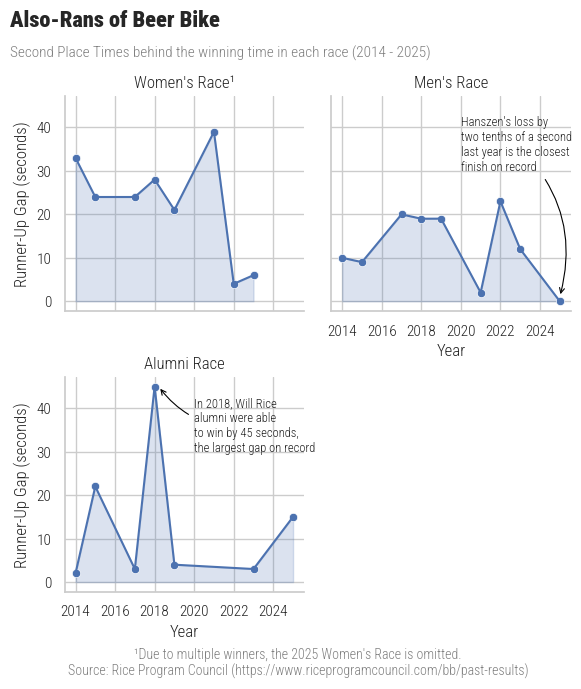

In [266]:
winning_times = times.group_by("Year", "Race").agg(
    pl.col("Total_Secs").min().alias("Best_Time"),
    pl.col("College").first().alias("Winning_College")
)
time_diff = times.join(winning_times, on = ["Year", "Race"]).with_columns(
    (pl.col("Total_Secs") - pl.col("Best_Time")).alias("Time_Off")
).filter(pl.col("Ranking") == "2").sort(by = "Time_Off", descending = True).filter(pl.col("Race").is_in(["A", "W", "M"])).sort(by = "Year")

#sns.histplot(data = time_diff.to_pandas(), x = "Time_Off")
#sns.scatterplot(data = time_diff.to_pandas(), y = "Year", x = "Total_Secs", hue = "Race", palette = sns.color_palette("tab10"), alpha = 0.7)
#time_diff.select("Year").unique()
import matplotlib.ticker as ticker

g = sns.FacetGrid(time_diff.to_pandas(), col="Race", col_wrap = 2)

g.map_dataframe(sns.lineplot, x="Year", y="Time_Off")

g.map_dataframe(
    lambda data, color, **kws: plt.fill_between(
        data["Year"],
        data["Time_Off"],
        color=color,
        alpha=0.2
    )
)

g.map_dataframe(sns.scatterplot, x="Year", y="Time_Off")



for ax in g.axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    race_labels = {
        "W": "Women's Race¹",
        "M": "Men's Race",
        "A": "Alumni Race"
    }
    title = ax.get_title().split(" = ")[-1]
    ax.set_title(race_labels.get(title, title))
g.fig.suptitle(
    "Also-Rans of Beer Bike",
    fontsize=16,
    fontweight="bold",
    x=0.02,
    y = 1.08,
    ha="left"
)
g.fig.text(
    0.02, 1,
    "Second Place Times behind the winning time in each race (2014 - 2025)",
    ha="left",
    fontsize=11,
    color="gray",
)
closest = g.axes.flat[1]
closest.annotate(
    "Hanszen's loss by\ntwo tenths of a second\nlast year is the closest\nfinish on record",
    xy=(2025, 1),
    xytext=(2020, 30),
    arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8,
            connectionstyle="arc3,rad=-0.3"
        ),
    fontsize=9,
)

farthest = g.axes.flat[2]
farthest.annotate(
    "In 2018, Will Rice\nalumni were able\nto win by 45 seconds,\nthe largest gap on record",
    xy=(2018.2, 45),
    xytext=(2020, 30),
    arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8,
            connectionstyle="arc3,rad=-0.3"
        ),
    fontsize=9,
)
footer_text = "¹Due to multiple winners, the 2025 Women's Race is omitted.\nSource: Rice Program Council (https://www.riceprogramcouncil.com/bb/past-results)"
plt.figtext(0.5, -0.03, footer_text, ha="center", fontsize=10, color="gray")
g.set_ylabels("Runner-Up Gap (seconds)")

In [267]:
counts = (
    historical_results.unpivot(
        index="Year",
        on=["Men's", "Women's", "Alumni"],
        variable_name="Race",
        value_name="Team"
    )
    .group_by(["Year", "Team"])
    .agg(pl.len().alias("wins_that_year"))
    .sort(["Year", "wins_that_year"], descending=[False, True])
)
yrs = counts.filter((pl.col("wins_that_year") == 2) & (pl.col("Team").is_not_null()) & (pl.col("Team") != "Dummy")).get_column("Year")
stops = counts.filter(pl.col("Year").is_in(yrs) & (pl.col("wins_that_year") == 1) & pl.col("Team").is_not_null()).filter(pl.col("Year") != 2025) #add one to will rice at end
#stops = stops.group_by("Team").agg(pl.count().alias("num_stops")).sort("num_stops", descending = True)

/var/folders/7y/5jxbr6lx7hq89nzmg4f587ch0000gn/T/ipykernel_77140/564518537.py:13: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  stops = counts.filter(pl.col("Year").is_in(yrs) & (pl.col("wins_that_year") == 1) & pl.col("Team").is_not_null()).filter(pl.col("Year") != 2025) #add one to will rice at end


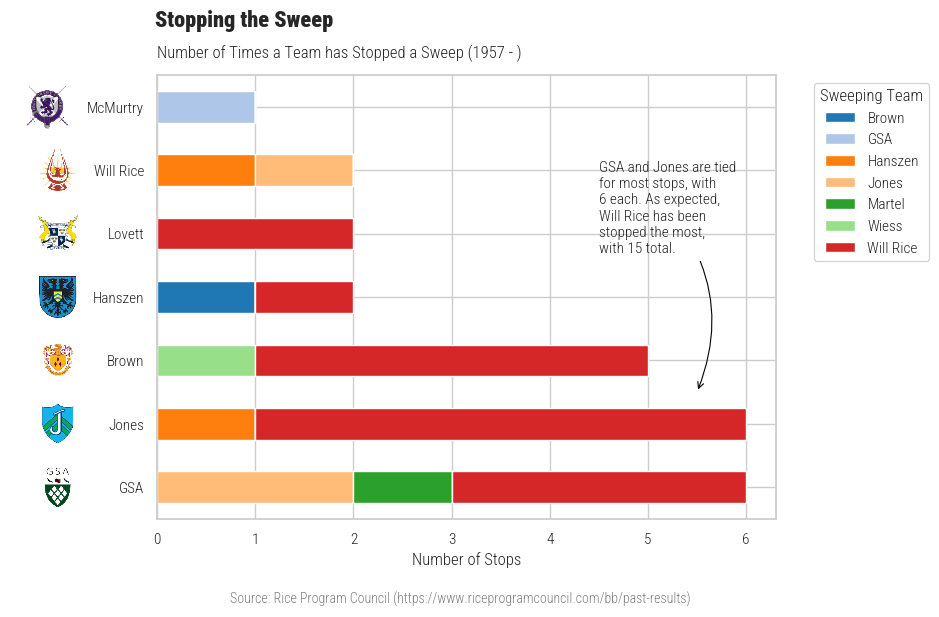

In [268]:
from htmltools import img


alm_sweeps = counts.filter((pl.col("wins_that_year") == 2) & (pl.col("Team").is_not_null()) & (pl.col("Team") != "Dummy"))
alm_sweeps = alm_sweeps.join(stops.select("Year", "Team"), on = "Year", suffix = "_stop").select("Year", "Team", "Team_stop")
wrc_2025 = pl.DataFrame([{"Year": 2025, "Team": "Will Rice", "Team_stop": "Hanszen"}])
alm_sweeps.extend(wrc_2025)
counts_pd = (
    alm_sweeps
    .group_by(["Team", "Team_stop"])
    .agg(pl.len().alias("count"))
)
counts_pd = counts_pd.to_pandas()
pivot = counts_pd.pivot(
    index="Team_stop",
    columns="Team",
    values="count"
).fillna(0)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]


fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=sns.color_palette("tab20")
)

logo_path = "../data/college_logos_png"

for i, team in enumerate(pivot.index):
    img_path = os.path.join(logo_path, f"{team}.png")
    if team == "Will Rice":
        img_path = os.path.join(logo_path, f"wrc.png")
    if team == "McMurtry":
        img_path = os.path.join(logo_path, f"murt.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        imagebox = OffsetImage(img, zoom=0.3)
        if team == "McMurtry":
            imagebox = OffsetImage(img, zoom=0.45) 
        
        ab = AnnotationBbox(
            imagebox,
            (-.8, i),         
            frameon=False,
            xycoords=("data", "data"),
            box_alignment=(1, 0.5) 
        )
        
        ax.add_artist(ab)

xmin, xmax = ax.get_xlim()
ax.annotate(
    "GSA and Jones are tied\nfor most stops, with\n6 each. As expected,\nWill Rice has been\nstopped the most,\nwith 15 total.",
    xy=(5.5, 1.5),
    xytext=(4.5, 3.7),
    arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8,
            connectionstyle="arc3,rad=-0.3"
        ),
    fontsize=11,
)
plt.xlabel("Number of Stops")
plt.ylabel("")
plt.title("Number of Times a Team has Stopped a Sweep (1957 - )", y=1.02, x=0, ha="left")

plt.legend(title="Sweeping Team", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle("Stopping the Sweep", fontsize=16, fontweight="bold", y=0.96, x=0.195, ha="left")
footer_text = "Source: Rice Program Council (https://www.riceprogramcouncil.com/bb/past-results)"
plt.figtext(0.5, -0.03, footer_text, ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.show()

Text(0.5, -0.08, 'Note: Times were not recorded for all years. We also cannot guarantee that race lengths were consistent.\nSource: Rice Program Council (https://www.riceprogramcouncil.com/bb/past-results)')

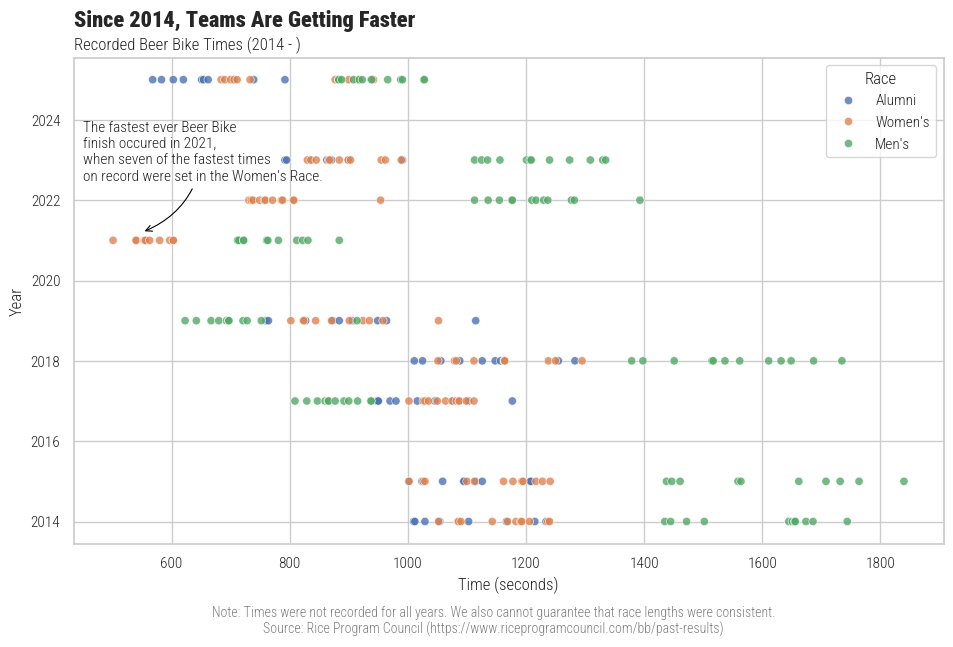

In [269]:
fig, ax = plt.subplots(figsize=(10, 6))
times_df = times.with_columns(
    pl.when(pl.col("Race").is_in(["W1", "W2"])).then(pl.lit("W")).otherwise(pl.col("Race")).alias("Race")
).to_pandas()
p = sns.scatterplot(data = times_df, y = "Year", x = "Total_Secs", hue = "Race", alpha = 0.8)
ax.set_xlabel("Time (seconds)")
ax.annotate(
    "The fastest ever Beer Bike\nfinish occured in 2021,\nwhen seven of the fastest times\non record were set in the Women's Race.",
    xy=(550, 2021.2),
    xytext=(450, 2022.5),
    arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8,
            connectionstyle="arc3,rad=-0.3"
        ),
    fontsize=11,
)
handles, labels = ax.get_legend_handles_labels()

new_labels = {
    "M": "Men's",
    "W": "Women's",
    "A": "Alumni"
}

labels = [new_labels.get(l, l) for l in labels]

ax.legend(handles, labels, title="Race")
plt.title("Recorded Beer Bike Times (2014 - )", y=1.0, x=0, ha="left")


plt.suptitle("Since 2014, Teams Are Getting Faster", fontsize=16, fontweight="bold", y=0.96, x=0.08, ha="left")
footer_text = "Note: Times were not recorded for all years. We also cannot guarantee that race lengths were consistent.\nSource: Rice Program Council (https://www.riceprogramcouncil.com/bb/past-results)"
plt.figtext(0.5, -0.08, footer_text, ha="center", fontsize=10, color="gray")

In [276]:
times.filter(pl.col("Race") == "W").with_columns(
    (pl.col("Total_Secs") / 8).alias("avg_per_racer")
).sort("avg_per_racer")

Year,Race,Ranking,College,Time,Points,Total_Secs,avg_per_racer
i64,str,str,str,str,i32,f64,f64
2021,"""W""","""1""","""McMurtry""","""08:21.3""",3,501.003,62.625375
2021,"""W""","""2""","""Jones""","""09:00.0""",2,540.0,67.5
2021,"""W""","""2""","""Hanszen""","""09:00.0""",2,540.0,67.5
2021,"""W""","""3""","""Will Rice""","""09:13.0""",1,553.0,69.125
2021,"""W""","""4""","""Duncan""","""09:14.2""",0,554.002,69.25025
…,…,…,…,…,…,…,…
2018,"""W""","""8""","""Hanszen""","""20:38.1""",0,1238.001,154.750125
2014,"""W""","""12""","""Hanszen""","""20:40""",0,1240.0,155.0
2015,"""W""","""12""","""Brown""","""20:41""",0,1241.0,155.125
